<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Data%20Understanding/Synthetic_Kurtosis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Synthetic Kurtosis
Data Centric AI – Data Understanding

Three synthetic datasets with the **same mean (10), the same standard deviation (2) and skewness = 0** but a different **kurtosis**:

| Dataset | Generating distribution | Expected kurtosis κ |
|---|---|---|
| 1 | Uniform | 1.8 (platykurtic) |
| 2 | Normal | 3 (mesokurtic) |
| 3 | Laplace | 6 (leptokurtic) |

Skewness cannot distinguish them; kurtosis tells how much of the variance is due to rare, extreme values.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

rng = np.random.default_rng(105)
N_HALF, MEAN, STD = 100, 10, 2

def symmetric_standardized(sample):
    # mirror the sample around 0 (skewness exactly 0), then force mean=MEAN and std=STD
    x = np.concatenate([sample, -sample])
    x = (x - x.mean()) / x.std()
    return MEAN + STD * x

datasets = {
    "Dataset 1 Distribution (Platykurtic)": (symmetric_standardized(rng.uniform(-1, 1, N_HALF)), "skyblue"),
    "Dataset 2 Distribution (Mesokurtic)":  (symmetric_standardized(rng.normal(0, 1, N_HALF)), "lightcoral"),
    "Dataset 3 Distribution (Leptokurtic)": (symmetric_standardized(rng.laplace(0, 1, N_HALF)), "mediumseagreen"),
}
for name, (x, _) in datasets.items():
    print(f"{name:40s} mean={x.mean():.2f} std={x.std():.2f} skewness={skew(x):+.4f} "
          f"kurtosis={kurtosis(x, fisher=False):.4f} (excess={kurtosis(x):+.4f}) "
          f"share beyond ±2.5σ={np.mean(np.abs(x - MEAN) > 2.5 * STD):.1%}")

Dataset 1 Distribution (Platykurtic)     mean=10.00 std=2.00 skewness=-0.0000 kurtosis=1.8631 (excess=-1.1369) share beyond ±2.5σ=0.0%
Dataset 2 Distribution (Mesokurtic)      mean=10.00 std=2.00 skewness=+0.0000 kurtosis=2.9910 (excess=-0.0090) share beyond ±2.5σ=1.0%
Dataset 3 Distribution (Leptokurtic)     mean=10.00 std=2.00 skewness=-0.0000 kurtosis=5.8157 (excess=+2.8157) share beyond ±2.5σ=4.0%


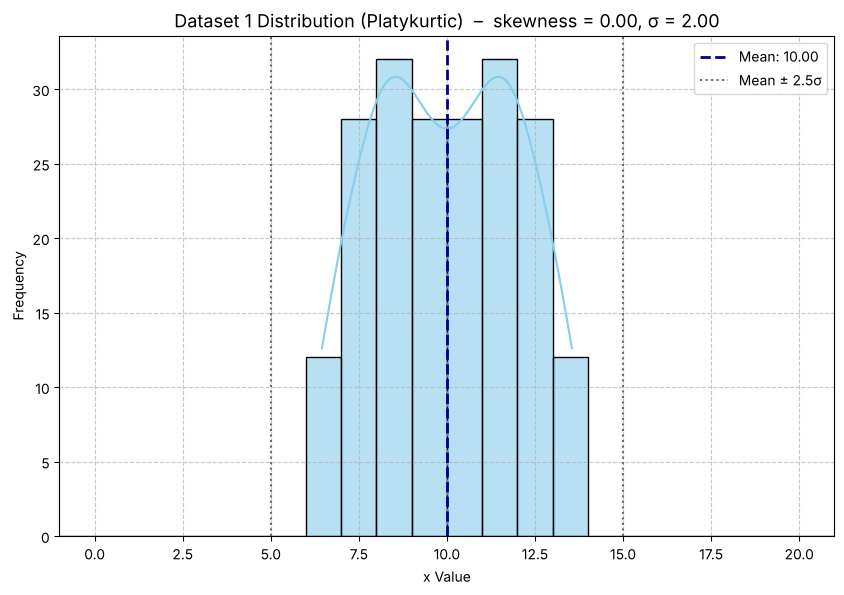

Kurtosis: 1.8631


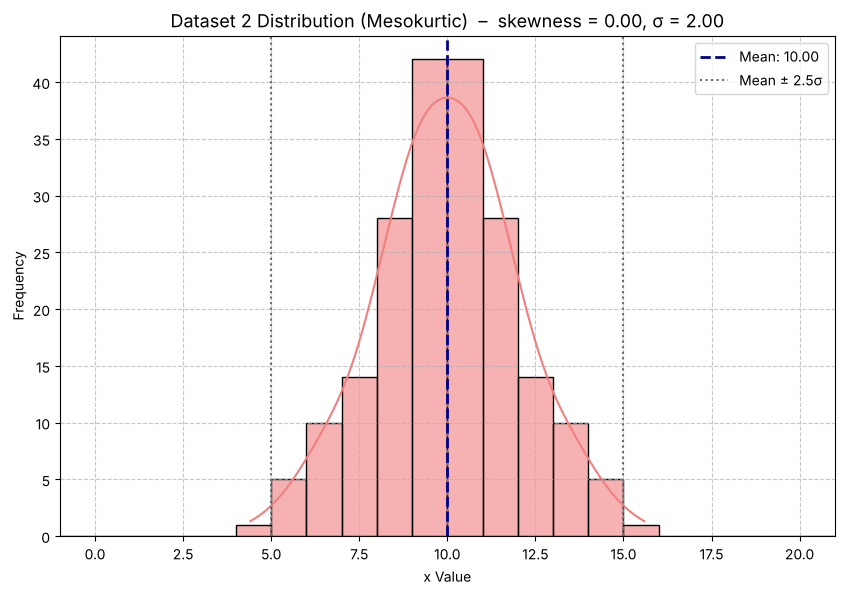

Kurtosis: 2.9910


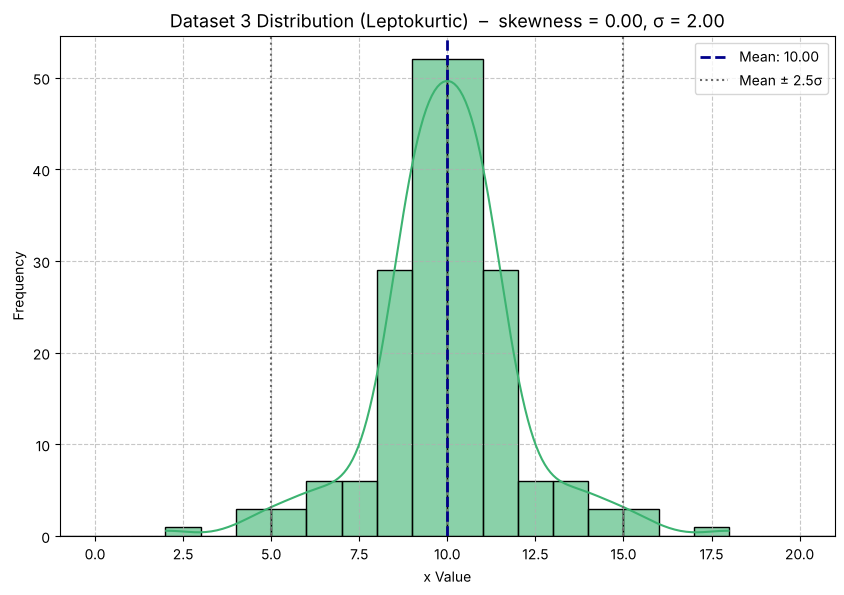

Kurtosis: 5.8157


In [ ]:
bins = np.arange(-1, 21.01, 1.0)
for i, (name, (x, color)) in enumerate(datasets.items(), start=1):
    k = kurtosis(x, fisher=False)
    fig, ax = plt.subplots(figsize=(10, 6.5))
    sns.histplot(x, bins=bins, kde=True, color=color, edgecolor="black", alpha=0.6, ax=ax)
    ax.axvline(x.mean(), color="darkblue", ls="--", lw=2, label=f"Mean: {x.mean():.2f}")
    for s in (-2.5, 2.5):
        ax.axvline(MEAN + s * STD, color="dimgray", ls=":", lw=1.5, label="Mean ± 2.5σ" if s < 0 else None)
    ax.set_xlim(-1, 21)
    ax.set_title(f"{name}  –  skewness = {round(skew(x), 2) + 0.0:.2f}, σ = {x.std():.2f}", fontsize=13)
    ax.set_xlabel("x Value"); ax.set_ylabel("Frequency")
    ax.grid(True, ls="--", alpha=0.7)
    ax.legend(loc="upper right")
    fig.savefig(f"kurtosis_dataset{i}.png", dpi=150, bbox_inches=None)
    plt.show()
    print(f"Kurtosis: {k:.4f}")